# German Electricity Demand Forecasting

## Part 3: Benchmark Forecasting Models

This notebook implements several benchmark forecasting methods for weekly German electricity demand. These models provide baseline performance against which more advanced forecasting methods such as ARMA, SARIMA, SARIMAX, feature-based regression and LSTM will be compared.

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import warnings
warnings.filterwarnings("ignore")

## Load Weekly Electricity Demand

The processed weekly electricity demand series is loaded and divided into training and testing datasets. The final two years (104 weeks) are reserved for forecast evaluation.

In [3]:
# Load weekly electricity demand

weekly_load = pd.read_csv(
    "/content/weekly_load.csv",
    parse_dates=["timestamp"],
    index_col="timestamp"
)

weekly_load.head()

,load
timestamp,
2015-01-04 00:00:00+00:00,47233.739583
2015-01-11 00:00:00+00:00,56191.101190
2015-01-18 00:00:00+00:00,57672.678571
2015-01-25 00:00:00+00:00,58613.303571
2015-02-01 00:00:00+00:00,58734.029762


In [4]:
# Split into training and testing data

forecast_horizon = 104

train = weekly_load.iloc[:-forecast_horizon]

test = weekly_load.iloc[-forecast_horizon:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 197
Testing observations: 104


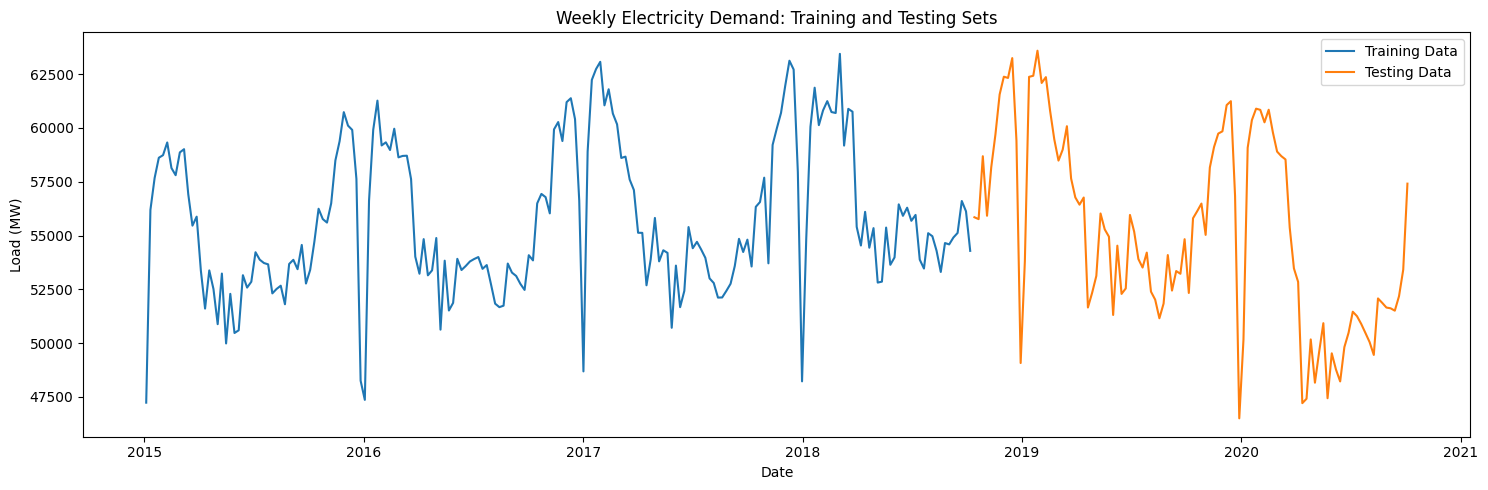

In [5]:
# Plot training and testing datasets

plt.figure(figsize=(15,5))

plt.plot(
    train.index,
    train["load"],
    label="Training Data"
)

plt.plot(
    test.index,
    test["load"],
    label="Testing Data"
)

plt.title("Weekly Electricity Demand: Training and Testing Sets")

plt.xlabel("Date")
plt.ylabel("Load (MW)")

plt.legend()

plt.tight_layout()

plt.savefig(
    "train_test_split.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Forecast Evaluation Function

A reusable evaluation function is defined to calculate the forecasting accuracy of each benchmark model. The evaluation metrics used are:

- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)
- MAPE (Mean Absolute Percentage Error)

These metrics will be used consistently throughout the assignment to compare all forecasting models.

In [6]:
# Function to calculate forecasting performance

def evaluate_forecast(actual, forecast):
    """
    Calculate forecasting accuracy metrics.

    Parameters
    ----------
    actual : array-like
        Actual observed values.

    forecast : array-like
        Forecasted values.

    Returns
    -------
    dict
        Dictionary containing RMSE, MAE and MAPE.
    """

    rmse = np.sqrt(mean_squared_error(actual, forecast))

    mae = mean_absolute_error(actual, forecast)

    mape = mean_absolute_percentage_error(actual, forecast) * 100

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    }

In [7]:
# Function to calculate forecasting performance

def evaluate_forecast(actual, forecast):
    """
    Calculate forecasting accuracy metrics.

    Parameters
    ----------
    actual : array-like
        Actual observed values.

    forecast : array-like
        Forecasted values.

    Returns
    -------
    dict
        Dictionary containing RMSE, MAE and MAPE.
    """

    rmse = np.sqrt(mean_squared_error(actual, forecast))

    mae = mean_absolute_error(actual, forecast)

    mape = mean_absolute_percentage_error(actual, forecast) * 100

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    }

## Mean Forecast

The Mean Forecast predicts every future observation as the average value of the training dataset.

Although this is a simple benchmark model, it provides an important baseline for comparing more advanced forecasting techniques.

In [8]:
# Calculate the average weekly electricity demand from the training data

mean_value = train["load"].mean()

# Generate the Mean Forecast for the entire forecast horizon

mean_forecast = np.repeat(
    mean_value,
    forecast_horizon
)

# Evaluate the forecast performance

mean_metrics = evaluate_forecast(
    test["load"],
    mean_forecast
)

# Display evaluation metrics

mean_results = pd.DataFrame([mean_metrics], index=["Mean Forecast"])

display(mean_results)

,RMSE,MAE,MAPE
Mean Forecast,4397.299694,3788.833122,6.969238


## Mean Forecast Results

The forecast produced by the Mean model is compared with the observed weekly electricity demand over the two-year test period.

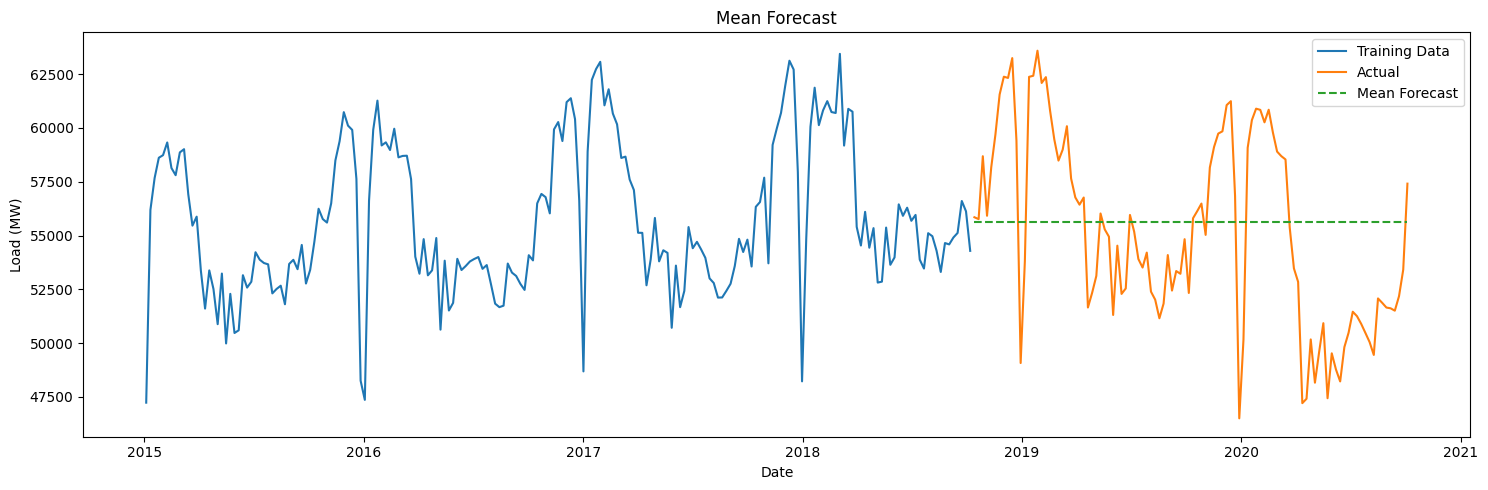

In [9]:
# Plot Mean Forecast

plt.figure(figsize=(15,5))

plt.plot(
    train.index,
    train["load"],
    label="Training Data"
)

plt.plot(
    test.index,
    test["load"],
    label="Actual"
)

plt.plot(
    test.index,
    mean_forecast,
    label="Mean Forecast",
    linestyle="--"
)

plt.title("Mean Forecast")

plt.xlabel("Date")
plt.ylabel("Load (MW)")

plt.legend()

plt.tight_layout()

plt.savefig(
    "mean_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Naïve Forecast

The Naïve Forecast predicts all future observations using the final value observed in the training dataset. This benchmark is commonly used in time series forecasting because many real-world series exhibit persistence.

In [10]:
# Obtain the last observed value from the training dataset

last_value = train["load"].iloc[-1]

# Generate the Naïve Forecast

naive_forecast = np.repeat(
    last_value,
    forecast_horizon
)

# Evaluate forecast performance

naive_metrics = evaluate_forecast(
    test["load"],
    naive_forecast
)

# Display evaluation metrics

naive_results = pd.DataFrame(
    [naive_metrics],
    index=["Naïve Forecast"]
)

display(naive_results)

,RMSE,MAE,MAPE
Naïve Forecast,4459.108546,3783.202934,6.790082


## Naïve Forecast Results

The forecast is compared with the observed electricity demand during the testing period.

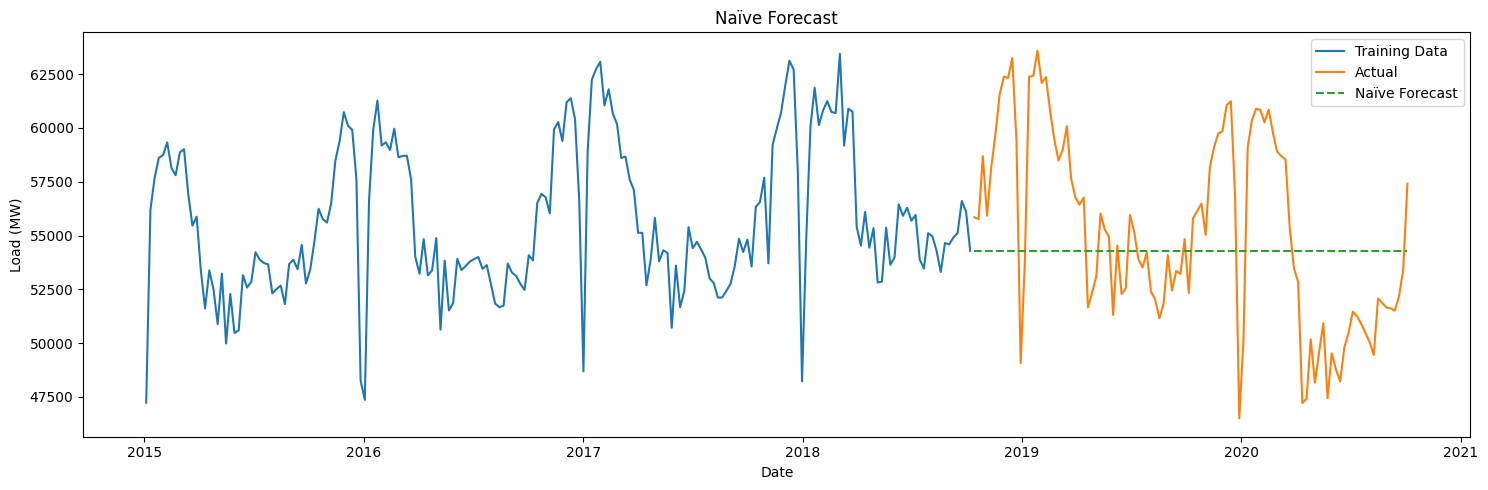

In [11]:
# Plot the Naïve Forecast

plt.figure(figsize=(15,5))

plt.plot(
    train.index,
    train["load"],
    label="Training Data"
)

plt.plot(
    test.index,
    test["load"],
    label="Actual"
)

plt.plot(
    test.index,
    naive_forecast,
    "--",
    label="Naïve Forecast"
)

plt.title("Naïve Forecast")

plt.xlabel("Date")
plt.ylabel("Load (MW)")

plt.legend()

plt.tight_layout()

plt.savefig(
    "naive_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()